In [1]:
import sys

# Load github repo
!git clone https://github.com/erezpoliak/AnimalClassifier

sys.path.append('/content/AnimalClassifier/EX4 - Project')

Cloning into 'AnimalClassifier'...
remote: Enumerating objects: 2079, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 2079 (delta 61), reused 79 (delta 25), pack-reused 1962 (from 2)
Receiving objects: 100% (2079/2079), 45.59 MiB | 50.75 MiB/s, done.
Resolving deltas: 100% (62/62), done.


In [2]:
from torchvision import datasets, transforms

# Download CIFAR-10 dataset
cifar_train = datasets.CIFAR10(root='./data_cifar', train=True, download=True, transform=transforms.ToTensor())
cifar_test = datasets.CIFAR10(root='./data_cifar', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:02<00:00, 81.8MB/s]


# Data Exploration

In [3]:
# Basic Info

print(f'CIFAR-10 Train Size: {len(cifar_train)}')
print(f'CIFAR-10 Test Size: {len(cifar_test)}')
print(f'CIFAR-10 Classes: {cifar_train.classes}')
print(f'CIFAR-10 Classes Count: {len(cifar_train.classes)}')
print(f'CIFAR-10 Image Shape: {cifar_train[0][0].shape}')

CIFAR-10 Train Size: 50000
CIFAR-10 Test Size: 10000
CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR-10 Classes Count: 10
CIFAR-10 Image Shape: torch.Size([3, 32, 32])


In [4]:
# Class Distribution
from dataset_util import display_class_distribution

display_class_distribution(cifar_train)

frog: 5000
truck: 5000
deer: 5000
automobile: 5000
bird: 5000
horse: 5000
ship: 5000
cat: 5000
dog: 5000
airplane: 5000


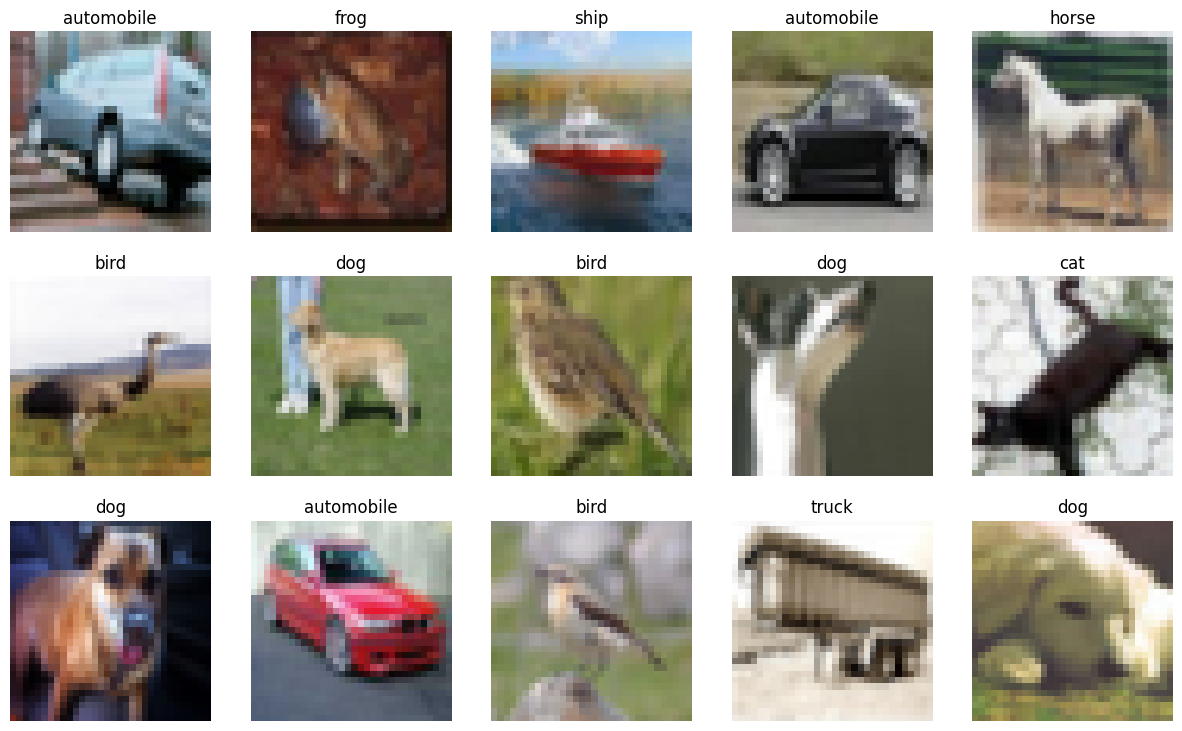

In [5]:
# Visualize few image samples
from dataset_util import display_image_samples

display_image_samples(cifar_train)

## Why CIFAR-10 for Transfer Learning?

**Dataset Relevance:**
- 6 overlapping classes with our dataset: bird, cat, deer, dog, horse, frog
- Natural images with similar visual patterns (textures, shapes, backgrounds)

**Transferable Features:**
- **Low-level**: Edge detection, texture patterns (fur/feathers), color gradients
- **Mid-level**: Body part detection (legs, heads, tails), shape recognition
- **High-level**: Animal vs non-animal discrimination, species characteristics

**Why This Helps:**
CIFAR-10's 50k images teach robust feature detectors. Even at lower resolution (32×32), convolutional filters learn transferable patterns that work on our higher resolution (224×224) animal images. Expected benefits: faster convergence and better generalization on our small (~2000 image) dataset.

# Pretraining on CIFAR-10

In [6]:
# Normalize (No augmentaion yet) + Split Train/Val/Test
from dataset_util import calculate_normalization_stats, get_normalized_transforms
from torch.utils.data import Subset
import numpy as np

mean_cifar, std_cifar = calculate_normalization_stats(cifar_train)
print(f'CIFAR-10 Mean: {mean_cifar}')
print(f'CIFAR-10 Std: {std_cifar}')

# Create transform
cifar_transform = get_normalized_transforms(mean_cifar, std_cifar, input_size = 32, augment = False)

# Load CIFAR-10 with transforms
cifar_train_transformed = datasets.CIFAR10(root='./data_cifar', train=True, download=False, transform=cifar_transform)
cifar_test_transformed = datasets.CIFAR10(root='./data_cifar', train=False, download=False, transform=cifar_transform)

# Split
train_indices = list(range(45000))
val_indices = list(range(45000, 50000))

cifar_train = Subset(cifar_train_transformed, train_indices)
cifar_val = Subset(cifar_train_transformed, val_indices)
cifar_test = cifar_test_transformed

CIFAR-10 Mean: [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
CIFAR-10 Std: [0.24703224003314972, 0.24348513782024384, 0.26158785820007324]


In [7]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Experiment 1

The goal of this experiment is to compare the CNN architecture originally selected for the animal dataset (without regularization techniques such as dropout or batch normalization) with a modified version that applies pooling every other layer instead of after each convolutional layer.

**The intuition:**

Since CIFAR-10 images are relatively small 32×32, aggressive downsampling may reduce the spatial resolution too quickly and lead to loss of important fine-grained features.

In contrast, the original animal dataset contained 224×224 images, where more frequent pooling is less problematic due to the larger initial spatial resolution.


In [9]:
from model_util import train
from CustomCNN import CustomCNN

BATCH_SIZE = 32
LR = 0.001
EPOCHS = 50
PATIENCE = 10
N_CLASSES = 10
INPUT_SIZE = 32

architecutres = {
    'Animal config': {
        'conv_layers': [32, 64, 128, 256],
        'fc_layers': [512, 256]
    },
    'Adapted to pool every other layer': {
        'conv_layers': [64,64,128,128,256,256],
        'fc_layers': [512,256]
    }
}

train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(cifar_val, batch_size=BATCH_SIZE, shuffle=False)

for config in architecutres:
  conv = architecutres[config]['conv_layers']
  fc = architecutres[config]['fc_layers']

  print(f'Architecture {config} - conv layers {conv}, fc layers {fc}')

  if config == 'Animal config - 1st notebook':
    model = CustomCNN(conv, fc, INPUT_SIZE, N_CLASSES).to(device)
  else:
    model = CustomCNN(conv, fc, INPUT_SIZE, N_CLASSES, pool_after=2).to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=LR)
  train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
  print()

Architecture Animal config - conv layers [32, 64, 128, 256], fc layers [512, 256]
Epoch 1/50 - Train Loss: 1.3267 - Train Acc: 0.5493 - Val Loss: 0.9993 - Val Acc: 0.6438
Epoch 5/50 - Train Loss: 0.2919 - Train Acc: 0.9010 - Val Loss: 0.9245 - Val Acc: 0.7518
Epoch 10/50 - Train Loss: 0.1222 - Train Acc: 0.9614 - Val Loss: 1.5059 - Val Acc: 0.7498
Early stopping at epoch 13

Architecture Adapted to pool every other layer - conv layers [64, 64, 128, 128, 256, 256], fc layers [512, 256]
Epoch 1/50 - Train Loss: 1.4096 - Train Acc: 0.4947 - Val Loss: 0.9974 - Val Acc: 0.6528
Epoch 5/50 - Train Loss: 0.5343 - Train Acc: 0.8139 - Val Loss: 0.7415 - Val Acc: 0.7542
Epoch 10/50 - Train Loss: 0.2712 - Train Acc: 0.9086 - Val Loss: 0.9177 - Val Acc: 0.7742
Early stopping at epoch 14



**insight:**

We can see the adapted architecture with pooling every other layer achieved better val acc, and overfitted much less severly than the original config, although still overfits.

We will move on with the adapted architecture.

### Experiment - Batch Normalization

In [10]:
FC = architecutres['Adapted to pool every other layer']['fc_layers']
CONV = architecutres['Adapted to pool every other layer']['conv_layers']

print('Batch Norm')
model = CustomCNN(CONV, FC, INPUT_SIZE, N_CLASSES, pool_after=2, batch_norm=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

Batch Norm
Epoch 1/50 - Train Loss: 2.7247 - Train Acc: 0.4094 - Val Loss: 1.3212 - Val Acc: 0.5456
Epoch 5/50 - Train Loss: 0.6260 - Train Acc: 0.7855 - Val Loss: 0.6701 - Val Acc: 0.7760
Epoch 10/50 - Train Loss: 0.2119 - Train Acc: 0.9271 - Val Loss: 0.5897 - Val Acc: 0.8368
Epoch 15/50 - Train Loss: 0.0826 - Train Acc: 0.9722 - Val Loss: 0.7114 - Val Acc: 0.8424
Early stopping at epoch 19



**Intersting Comparison to batch norm experiment in last notebook:**

In the animal model, BN failed, producing worse performance and severe training instability.

However here, BN really healped, improving val acc by ~7%.

Possible explanation, why it works well in this case:
- Final feature map: 256×4×4 = 4,096 features
- Batch norm normalizes compact, semantic representations
- Moderate 4k -> 512 bottleneck (87% reduction) is manageable after normalization, much less severe than 50k -> 512.

Because BN helped we will continue to use it for this model.

We will test now regularization techniques as the model suffers from overfitting issue.


### Experiment - Regularization techniques

- dropout only
- weight decay only
- data augmentation only

In [13]:
from dataset_util import get_normalized_transforms

DROPOUT = 0.2
WEIGHT_DECAY = 0.001

# Dropout only
print('Dropout Only')
model = CustomCNN(CONV, FC, INPUT_SIZE, N_CLASSES, pool_after=2, batch_norm=True, dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

# Weight Decay Only
print('Weight Decay Only')
model = CustomCNN(CONV, FC, INPUT_SIZE, N_CLASSES, pool_after=2, batch_norm=True)
optimizer_weight_decay = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
train(model, train_loader, val_loader, optimizer_weight_decay, EPOCHS, PATIENCE, device)

# Data Augmentation Only
print('Data Augmentation Only')
val_test_transform = get_normalized_transforms(mean_cifar, std_cifar, input_size = 32, augment = False)

# augment only train
train_transform = get_normalized_transforms(mean_cifar, std_cifar, input_size = 32, augment = True)

# Create a dataset for training with augmentation
cifar_train_augmented = datasets.CIFAR10(root='./data_cifar', train=True, download=False, transform=train_transform)
# Create a dataset for validation without augmentation
cifar_train_non_augmented = datasets.CIFAR10(root='./data_cifar', train=True, download=False, transform=val_test_transform)
cifar_test_transformed = datasets.CIFAR10(root='./data_cifar', train=False, download=False, transform=val_test_transform)

# Split
train_indices = list(range(45000))
val_indices = list(range(45000, 50000))

# Assign the final datasets
cifar_train = Subset(cifar_train_augmented, train_indices) # Training set is augmented
cifar_val = Subset(cifar_train_non_augmented, val_indices) # Validation set is NOT augmented
cifar_test = cifar_test_transformed # Test set is NOT augmented

train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(cifar_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)

model = CustomCNN(CONV, FC, INPUT_SIZE, N_CLASSES, pool_after=2, batch_norm=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train(model, train_loader, val_loader, optimizer, EPOCHS, PATIENCE, device)
print()

Dropout Only
Epoch 1/50 - Train Loss: 2.8835 - Train Acc: 0.2709 - Val Loss: 1.5989 - Val Acc: 0.4012
Epoch 5/50 - Train Loss: 1.0345 - Train Acc: 0.6416 - Val Loss: 0.8944 - Val Acc: 0.6972
Epoch 10/50 - Train Loss: 0.5505 - Train Acc: 0.8149 - Val Loss: 0.5710 - Val Acc: 0.8090
Epoch 15/50 - Train Loss: 0.2614 - Train Acc: 0.9146 - Val Loss: 0.4992 - Val Acc: 0.8420
Epoch 20/50 - Train Loss: 0.1351 - Train Acc: 0.9571 - Val Loss: 0.5530 - Val Acc: 0.8442
Early stopping at epoch 22

Weight Decay Only
Epoch 1/50 - Train Loss: 2.5659 - Train Acc: 0.4275 - Val Loss: 1.2366 - Val Acc: 0.5748
Epoch 5/50 - Train Loss: 0.6748 - Train Acc: 0.7692 - Val Loss: 0.7645 - Val Acc: 0.7448
Epoch 10/50 - Train Loss: 0.4397 - Train Acc: 0.8494 - Val Loss: 0.5434 - Val Acc: 0.8170
Epoch 15/50 - Train Loss: 0.3282 - Train Acc: 0.8874 - Val Loss: 0.4933 - Val Acc: 0.8400
Epoch 20/50 - Train Loss: 0.2803 - Train Acc: 0.9017 - Val Loss: 0.5677 - Val Acc: 0.8234
Epoch 25/50 - Train Loss: 0.2507 - Train Acc:

**Insights:**
- Dropout (0.2) preserves performance and improves overfitting, although not fixes it. It maybe beneficial to increase it slightly.
- Weight Decay (0.001) helped overfitting slightly better and preserves performance, while not fixing the issue entirely.
- Data augmentation similar to what we saw in cnn_scratch notebook, emerged as the clear winner, improving acc by ~3.5% and improving overfitting issue the best out of all the regularization techniques.

Conclusion: It will be beneficial to try combined approach.

We will use combined approach of weight decay, dropout and data augmentation.

We will try to decrease dropout slightly to 0.1 to not over regularize.

In [15]:
DROPOUT = 0.1

print('Combined approach')
model = CustomCNN(CONV, FC, INPUT_SIZE, N_CLASSES, pool_after=2, batch_norm=True, dropout=DROPOUT).to(device)
optimizer_weight_decay = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
model, history = train(model, train_loader, val_loader, optimizer_weight_decay, EPOCHS, PATIENCE, device)
print()

Combined approach
Epoch 1/50 - Train Loss: 2.8729 - Train Acc: 0.2967 - Val Loss: 1.5723 - Val Acc: 0.4160
Epoch 5/50 - Train Loss: 1.0215 - Train Acc: 0.6395 - Val Loss: 0.8738 - Val Acc: 0.7072
Epoch 10/50 - Train Loss: 0.6931 - Train Acc: 0.7656 - Val Loss: 0.6190 - Val Acc: 0.7932
Epoch 15/50 - Train Loss: 0.5834 - Train Acc: 0.8037 - Val Loss: 0.5161 - Val Acc: 0.8294
Epoch 20/50 - Train Loss: 0.5441 - Train Acc: 0.8154 - Val Loss: 0.5253 - Val Acc: 0.8282
Epoch 25/50 - Train Loss: 0.5161 - Train Acc: 0.8254 - Val Loss: 0.4591 - Val Acc: 0.8442
Epoch 30/50 - Train Loss: 0.5041 - Train Acc: 0.8298 - Val Loss: 0.4563 - Val Acc: 0.8430
Epoch 35/50 - Train Loss: 0.4962 - Train Acc: 0.8334 - Val Loss: 0.4562 - Val Acc: 0.8472
Epoch 40/50 - Train Loss: 0.4893 - Train Acc: 0.8350 - Val Loss: 0.5051 - Val Acc: 0.8258
Epoch 45/50 - Train Loss: 0.4811 - Train Acc: 0.8361 - Val Loss: 0.4455 - Val Acc: 0.8516
Early stopping at epoch 48



**Insights:**

- Best validation accuracy achievied ~85%

- Excellent generalization, loss gap ~0.03, Train loss and Val loss track each other closely during training

- Train val accuracies almost equal 0.836/0.851

- Stable training

Conclusion: The combined approach fixed overfitting issue, while not hurting performance too much.

This will be the Final Model

In [16]:
# save pretrained weights
torch.save(model.state_dict(), 'cifar10_pretrained.pth')
print('Pretrained model saved to cifar10_pretrained.pth')

Pretrained model saved to cifar10_pretrained.pth


# Evaluation

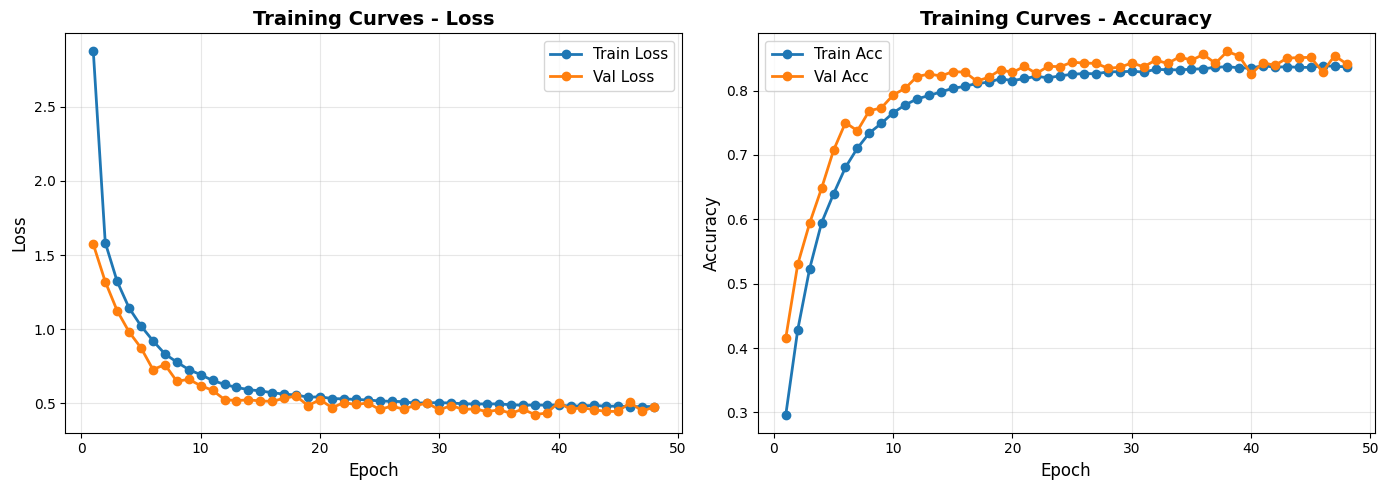

In [17]:
# Plot Training Curves
from model_util import plot_training_curves

plot_training_curves(history)

- We can see smooth convergences over the epochs with no sign of instability.

- Training and validation curves closely track each other, validating effective regularization, and no overfitting.

In [19]:
# Accuracy and loss on test set
from model_util import evaluate

test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)
test_loss, test_acc = evaluate(model, test_loader, device)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.5089
Test Accuracy: 0.8292


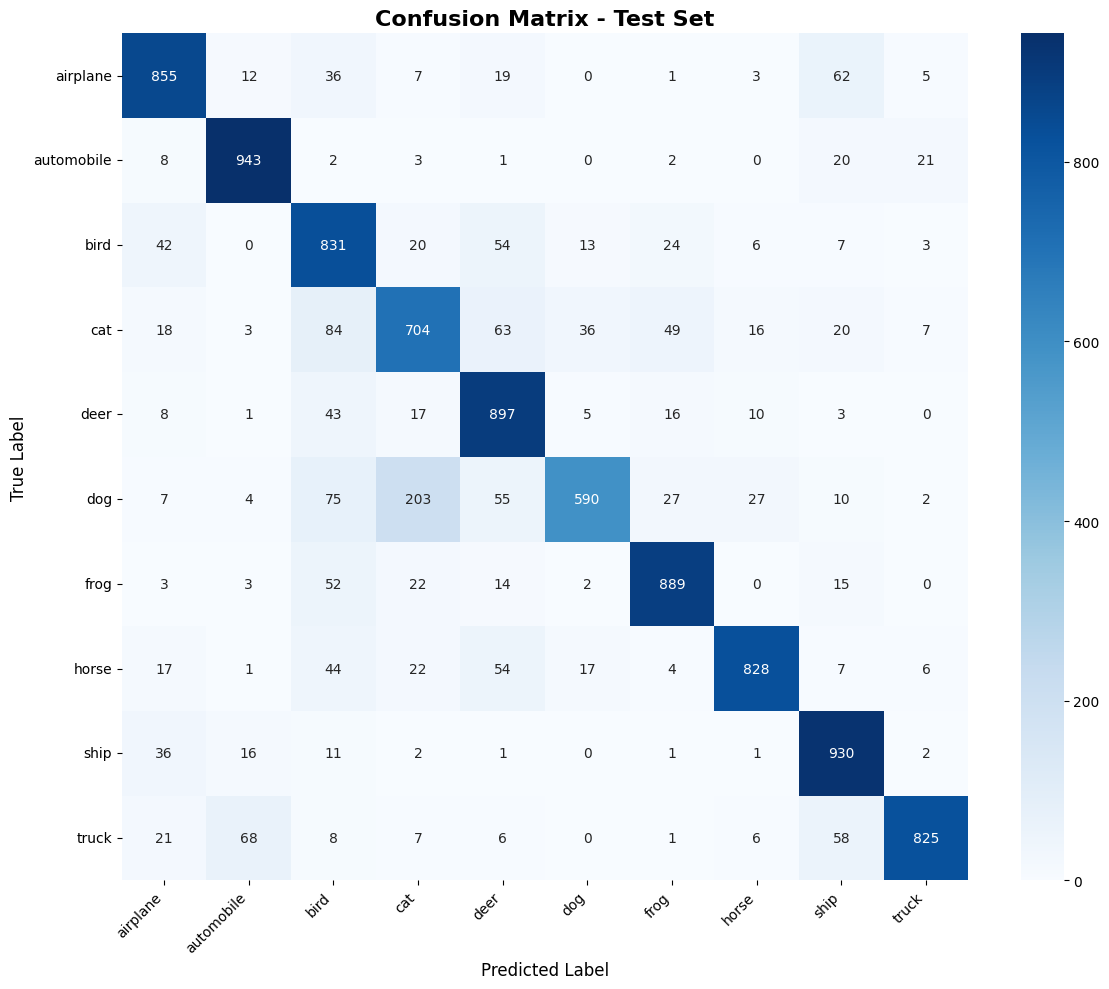

In [21]:
# Confusion matrix

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, test_loader, device, class_names):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      _, pred = torch.max(output.data, 1)
      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(target.cpu().numpy())

  cm = confusion_matrix(all_labels, all_preds)

  plt.figure(figsize=(12, 10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
  plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
  plt.ylabel('True Label', fontsize=12)
  plt.xlabel('Predicted Label', fontsize=12)
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()
  return cm

class_names = cifar_train_augmented.classes
cm = plot_confusion_matrix(model, test_loader, device, class_names)

- **Strong diagonal dominance**: Most predictions align with true labels, indicating effective class discrimination across most categories

- **Key confusions**: Cat-Dog show the highest misclassification rates, reflecting shared visual features (fur texture/body shape)

### The Final Model Architecutre And Parameters Summary:

- Batch size 32

- LR 0.001

- Optimizer Adam

- Conv layers 64, 64, 128, 128, 256, 256

- Fc layers 512, 256

- Epochs 50

- Patience 10

- Weight decay 0.001

- Dropout 0.1


Also used: Batch normalization, augmentation, and normalization on dataset.
Used Pooling every other layer.

# Fine tuning on animal dataset

In [34]:
# Load animal dataset, normalize and augment
from dataset_util import dataset_split, calculate_normalization_stats, get_normalized_transforms

animal_ds_data_path = '/content/AnimalClassifier/animal_data'

# Load with basic transforms
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
full_animal_ds = datasets.ImageFolder(animal_ds_data_path, transform=basic_transform)

# Split 70/15/15
animal_train_ds, animal_val_ds, test_ds = dataset_split(full_animal_ds, 0.7, 0.15)

# Calculate stats from train
mean, std = calculate_normalization_stats(animal_train_ds)

# Augment on train, Normalize both
animal_train_transform = get_normalized_transforms(mean, std, augment=True)
animal_val_test_transform = get_normalized_transforms(mean, std, augment=False)

animal_train_full = datasets.ImageFolder(animal_ds_data_path, transform=animal_train_transform)
animal_val_full = datasets.ImageFolder(animal_ds_data_path, transform=animal_val_test_transform)
animal_test_full = datasets.ImageFolder(animal_ds_data_path, transform=animal_val_test_transform)

animal_train, _, _ = dataset_split(animal_train_full, 0.7, 0.15)
_, animal_val, _ = dataset_split(animal_val_full, 0.7, 0.15)
_, _, animal_test = dataset_split(animal_test_full, 0.7, 0.15)

**Lower learning rate in fine tuning for:**

- LR 0.0001 (vs 0.001) allows gentle adaptation to our specific animal dataset while preserving transferable knowledge

- Prevent catastrophic forgetting of CIFAR-10 knowledge

**Architecture Adaptation:**

- Only conv layers transferred due to input dimension mismatch between CIFAR-10 (32×32) and animal dataset (224×224)

- Output layer adapted from 10 classes (CIFAR-10) to 15 classes (our animals)

- Conv filters learn patterns independent of spatial dimensions, making them perfectly transferable

**Increase epochs (and patience)**:

- Lower learning rate (0.0001 vs 0.001) requires more iterations to converge - each update makes smaller weight adjustments

- Fine-tuning adapts pretrained features gradually, needing extended training to properly adjust conv layers to new domain (224×224 animals vs 32×32 CIFAR-10)

- Increased to 100 epochs with patience=15 to allow sufficient time for convergence while maintaining early stopping protection against overfitting



In [38]:
# Fine tuning

print('Fine tuning on Animal Dataset')

input_size = 224
n_classes = 15
epochs = 100
patience = 15

model_finetune = CustomCNN(CONV, FC, input_size, n_classes, DROPOUT, batch_norm=True).to(device)

# Load pretrained weights
pretrained_dict = torch.load('cifar10_pretrained.pth')

# Filter out incompatible layers (FC and output layers have different sizes)
model_dict = model_finetune.state_dict()
pretrained_dict_filtered = {k: v for k, v in pretrained_dict.items()
                            if k.startswith('conv_layers') and k in model_dict and v.shape == model_dict[k].shape}

print(f'Loaded {len(pretrained_dict_filtered)}/{len(pretrained_dict)} layers from pretrained model')
print('Transferred layers:', list(pretrained_dict_filtered.keys()))
print()

# Load the filtered weights
model_finetune.load_state_dict(pretrained_dict_filtered, strict=False)

animal_train_loader = torch.utils.data.DataLoader(animal_train, batch_size=BATCH_SIZE, shuffle=True)
animal_val_loader = torch.utils.data.DataLoader(animal_val, batch_size=BATCH_SIZE, shuffle=False)
animal_test_loader = torch.utils.data.DataLoader(animal_test, batch_size=BATCH_SIZE, shuffle=False)

# Fine tune with lower learning rate
optimizer_finetune = torch.optim.Adam(model_finetune.parameters(), lr=0.0001, weight_decay=WEIGHT_DECAY)

model_fintune, history_finetune = train(model_finetune, animal_train_loader, animal_val_loader, optimizer_finetune, epochs, patience, device)

Fine tuning on Animal Dataset
Loaded 6/42 layers from pretrained model
Transferred layers: ['conv_layers.0.weight', 'conv_layers.1.weight', 'conv_layers.2.weight', 'conv_layers.3.weight', 'conv_layers.4.weight', 'conv_layers.5.weight']

Epoch 1/100 - Train Loss: 13.2404 - Train Acc: 0.1441 - Val Loss: 5.3052 - Val Acc: 0.1478
Epoch 5/100 - Train Loss: 3.4056 - Train Acc: 0.3243 - Val Loss: 1.8652 - Val Acc: 0.4399
Epoch 10/100 - Train Loss: 2.1355 - Train Acc: 0.4684 - Val Loss: 1.3297 - Val Acc: 0.6186
Epoch 15/100 - Train Loss: 1.6400 - Train Acc: 0.5493 - Val Loss: 1.0174 - Val Acc: 0.6632
Epoch 20/100 - Train Loss: 1.2599 - Train Acc: 0.6544 - Val Loss: 0.8330 - Val Acc: 0.7320
Epoch 25/100 - Train Loss: 0.9927 - Train Acc: 0.7022 - Val Loss: 0.8568 - Val Acc: 0.7285
Epoch 30/100 - Train Loss: 0.7514 - Train Acc: 0.7581 - Val Loss: 0.6398 - Val Acc: 0.8041
Epoch 35/100 - Train Loss: 0.5759 - Train Acc: 0.8132 - Val Loss: 0.4544 - Val Acc: 0.8797
Epoch 40/100 - Train Loss: 0.6322 - 

Best achieved val acc ~0.94, val loss ~0.29

Compared with from scratch approch: acc ~0.95, loss ~0.39

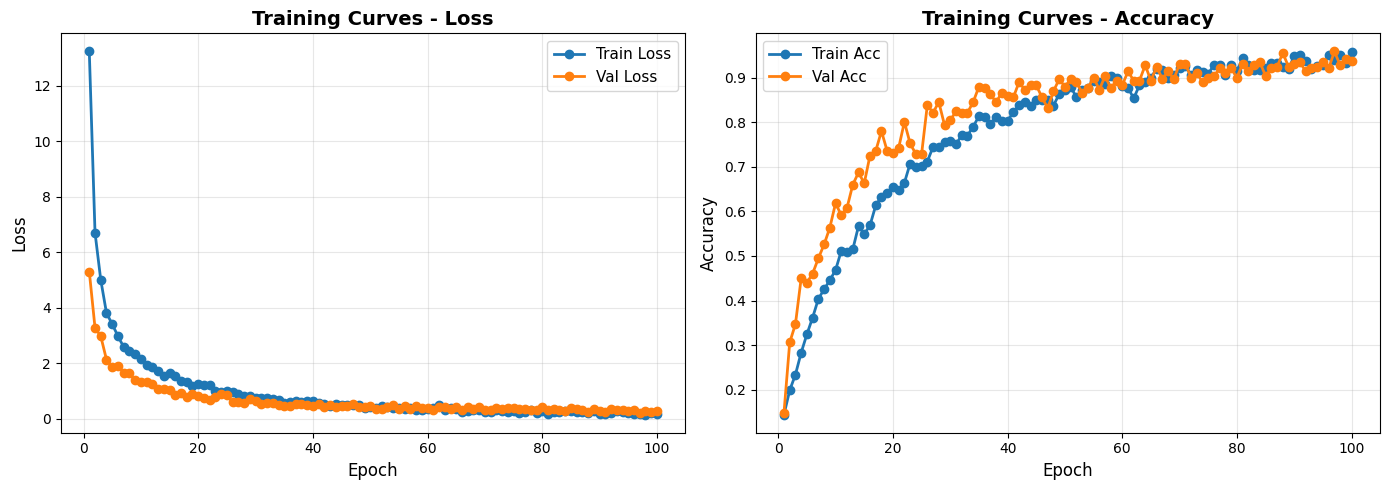

In [39]:
# Plot training curves

plot_training_curves(history_finetune)

Very stable training and smooth convergence, with no sign of overfitting

In [40]:
# Test Accuracy, Test Loss

test_loss, test_acc = evaluate(model_finetune, animal_test_loader, device)

print(f'Animal Test Loss: {test_loss:.4f}')
print(f'Animal Test Accuracy: {test_acc:.4f}')

Animal Test Loss: 0.3663
Animal Test Accuracy: 0.9181


Test Acc and Test Loss are very close to from scratch approach
Test Acc: ~92/~94 (transfer, from scratch)
Test Loss: ~0.37/~0.39 (transfer from scratch)

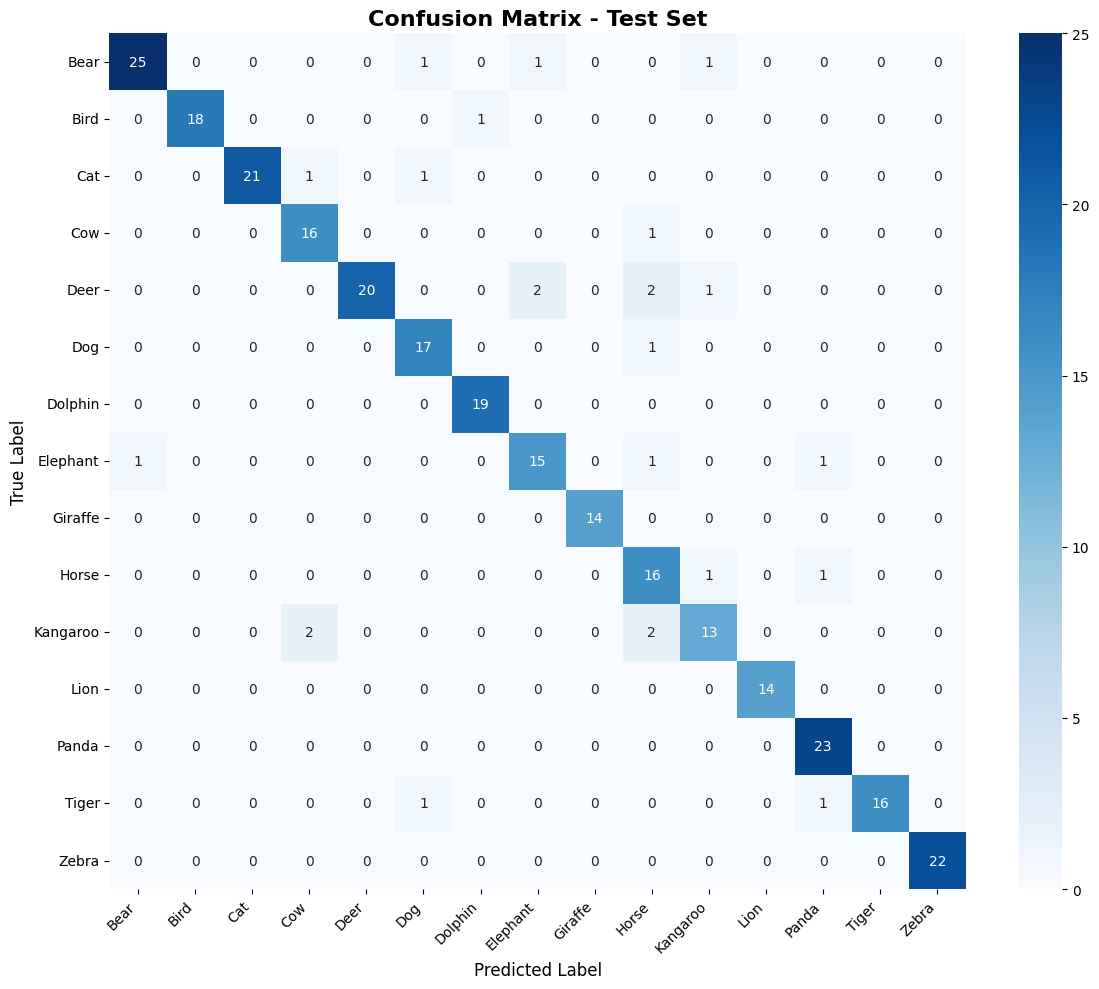

In [41]:
# Plot Confusion Matrix

animal_classes = full_animal_ds.classes
cm = plot_confusion_matrix(model_finetune, animal_test_loader, device, animal_classes)

- Strong diagonal dominance: Most predictions align with true labels, indicating effective class discrimination across all 15 animal categories

- Minimal inter-class confusion: Off-diagonal elements are sparse, confirming the model learned distinct features for each animal type

- Balanced performance: No single class shows severe misclassification, suggesting uniform model capability across the dataset

- Look about the same as from-scratch Confusion Matrix

## Transfer Learning vs From-Scratch: Comparison Analysis

### 1. Convergence Speed

**Epochs to Best Performance:**
- From-scratch: 25 epochs (early stop at 35)
- Transfer learning: 100 epochs
- **Result**: From-scratch converged in 1/4 of the epochs of Transfer Learning.

**Reason**: Higher LR (0.001 vs 0.0001) enabled faster convergence. Transfer learning's lower LR preserves pretrained features but requires more iterations to adapt from 32×32 CIFAR-10 to 224×224 animals.

---

### 2. Final Performance

| Metric | From-Scratch | Transfer Learning | Difference |
|--------|--------------|-------------------|------------|
| Val Accuracy | 95.19% | 93.81% | -1.38% |
| Test Accuracy | 93.86% | 91.81% | -2.05% |
| Test Loss | 0.390 | 0.3663 | -0.0237  |

**Key Findings:**
- Test accuracy (2% difference) in favor of from-scratch
- Transfer learning slightly better test loss, having more confident predictions.
- Val accuracy (1.4% difference) in favor of from-scratch

The final performance of the two approaches is very similar.

---

### 3. Generalization

**From-Scratch:**
- Train-val loss gap: ~0.12
- Val-test loss: 0.27 -> 0.390 (+0.12 increase)
- Consistent performance with slight test degradation

**Transfer Learning:**
- Train-val loss gap: ~0.12, exactly the same as from scratch
- Val-test loss: ~0.285 -> ~0.365 (+0.08 increase), slightly better than from scratch
- Better generalization to test set (33% smaller val-test gap)

**Key Insight**: Both models show identical behavior during training (train-val gap of 0.12), but **transfer learning generalizes better to truly unseen data** (8% vs 12% val-test loss increase). This suggests transfer learning's pre-trained features provide more robust representations that transfer better beyond the validation set, even though from-scratch achieved slightly higher validation accuracy through more aggressive dataset-specific fitting.

---

### 4. Conclusions

**From-Scratch Advantages:**
- Higher accuracy: +2.05% test accuracy (93.86% vs 91.81%)
- Better peak performance on this specific dataset

**Transfer Learning Advantages:**
- Better generalization: 33% smaller val-test loss gap (0.08 vs 0.12)
- More robust features that transfer better to unseen data


**Final Verdict:**
Both approaches performed similarly (~2% difference), with **from-scratch slightly preferable** (93.86% vs 91.81% test accuracy). The minimal transfer learning advantage can be explained by the **7× resolution mismatch** (32×32 -> 224×224): convolutional filters pre-trained on tiny CIFAR-10 images learned features at the wrong scale, providing limited benefit when fine-tuned on higher-resolution images. This demonstrates that pre-training resolution matters as much as domain similarity for effective transfer learning.